In [78]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

from qiskit import __version__
assert __version__ >= '2.0.0', 'Version 2.0.0 or later of Qiskit is required.'

from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakePerth
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram

from qiskit_experiments.library import T1

<h1> Simulation of T1 Experiment

In [69]:
backend = FakePerth()
sim = AerSimulator.from_backend(backend=backend)

In [143]:
delays = np.arange(0, 1e5, 1e1).tolist()

qcs = []

for delay in delays:
    qc = QuantumCircuit(1, 1)
    qc.x(0)  # Prepare the qubit in state |1>
    qc.delay(delay, 0, unit='ns')  # Apply a delay
    qc.measure(0, 0)
    qcs.append(qc)

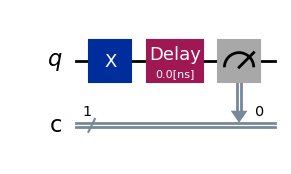

In [144]:
qcs[0].draw(output='mpl')

In [111]:
job = sim.run(qcs, shots=100)
result = job.result()

data = []
for i in result.get_counts():
    if '1' in i:
        data.append(i['1'])

Text(0.5, 1.0, 'T1 Experiment on Fake Perth')

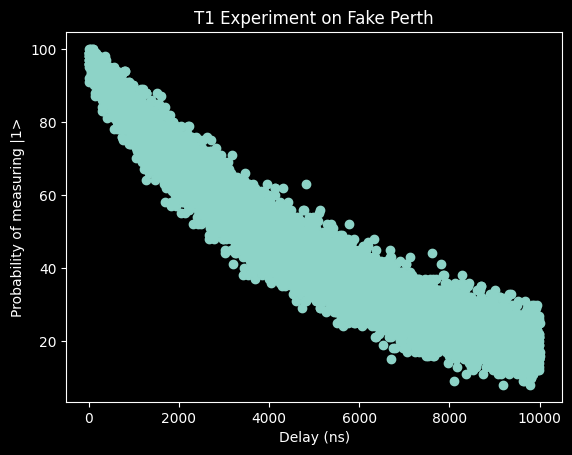

In [112]:
plt.plot(data, marker='o', linestyle='None')
plt.ylabel('Probability of measuring |1>')
plt.xlabel('Delay (ns)')
plt.title('T1 Experiment on Fake Perth')

In [113]:
from scipy.optimize import curve_fit
from scipy.stats import expon

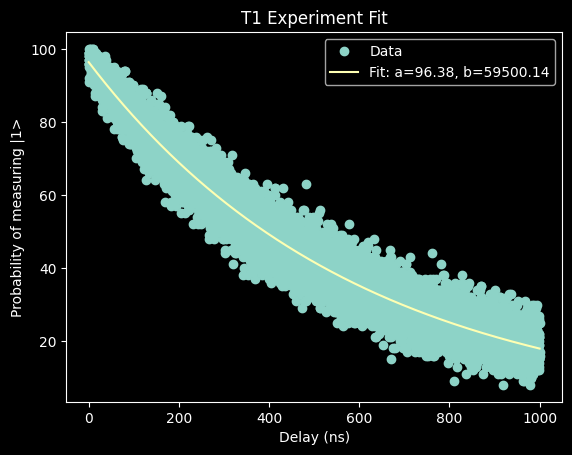

In [114]:
data = np.array(data)

def exp_fit(x, a, b):
    return a * np.exp(-x / b)

delays_ = np.array(delays)/100.0

params, _ = curve_fit(exp_fit, delays, data, p0=[1, 1e5])
plt.plot(delays_, data, marker='o', linestyle='None', label='Data')
plt.plot(delays_, exp_fit(np.array(delays), *params), label='Fit: a=%.2f, b=%.2f' % tuple(params))
plt.xlabel('Delay (ns)')
plt.ylabel('Probability of measuring |1>')
plt.title('T1 Experiment Fit')
plt.legend()

<h2> T_phi

In [122]:
delays = np.arange(0, 1e6, 2e2).tolist()

qcs = []

for delay in delays:
    qc = QuantumCircuit(1, 1)
    qc.x(0)  # Prepare the qubit in state |1>
    qc.h(0)  # Prepare the qubit in state |->
    qc.delay(delay, 0, unit='ns')  # Apply a delay
    qc.h(0)  # Return to computational basis
    qc.measure(0, 0)
    qcs.append(qc)

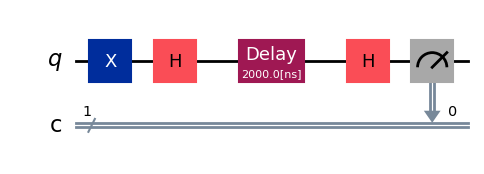

In [117]:
qcs[10].draw(output='mpl')

In [118]:
qcs_transpiled = transpile(qcs, backend=backend, optimization_level=3, scheduling_method="alap")

In [119]:
job = sim.run(qcs_transpiled, shots=100)
result = job.result()

data = []
for i in result.get_counts():
    if '1' in i:
        data.append(i['1'])

Text(0.5, 1.0, 'T_phi Experiment on Fake Perth')

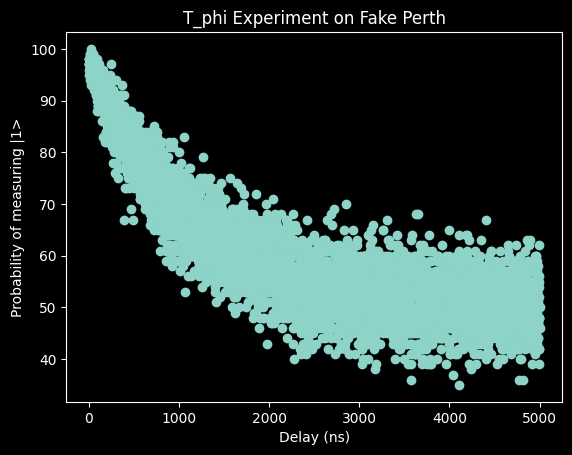

In [120]:
plt.plot(data, marker='o', linestyle='None')
plt.ylabel('Probability of measuring |1>')
plt.xlabel('Delay (ns)')
plt.title('T_phi Experiment on Fake Perth')

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\yehan\AppData\Local\Temp\ipykernel_27644\2432619966.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.title('$T_\phi$ Experiment Fit')


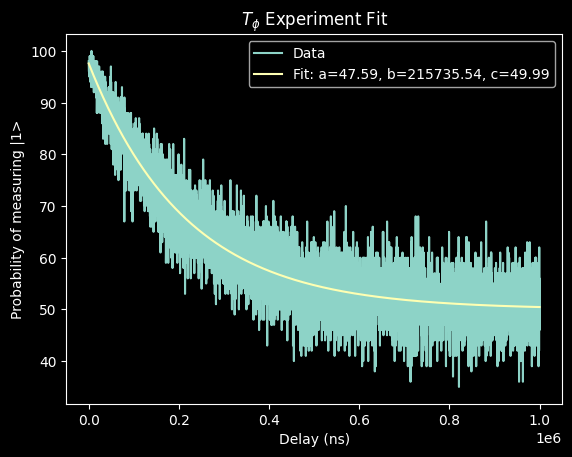

In [134]:
def exp_func(x, a, b, c):
    return a * np.exp(-x / b) + c

params, _ = curve_fit(exp_func, delays, data, p0=[1, 1e5, 0])

plt.plot(delays, data, label='Data')
plt.plot(delays, exp_func(np.array(delays), *params), label='Fit: a=%.2f, b=%.2f, c=%.2f' % tuple(params))
plt.xlabel('Delay (ns)')
plt.ylabel('Probability of measuring |1>')
plt.title('$T_\phi$ Experiment Fit')
plt.legend()

In [142]:
t1 = 60
t_phi = 215
print(f"T1: {t1:.2f} us, T_phi: {t_phi:.2f} us")

t2 = 1/(1/t1 + 1/(2*t_phi))
print(f"T2: {t2:.2f} us")

T1: 60.00 us, T_phi: 215.00 us
T2: 52.65 us
